# 基于Python的pftools的功能函数
## 主讲人：杨晨，中山大学大气科学学院

## 1. 从 TCL 到 Python

<img src="pftools_figs/tcl废弃.jpg" width="1000">

### * 手册说明（PFB和Hydrology Module）

<img src="pftools_figs/手册说明.jpg" width="300">

### * ParFlow内置tcl和python例子
### * ParFlow Python package位置

## 2. 如何用Python脚本配置一个ParFlow实例并运行
### * 请参考ParFlow中文社区的2个官方案例：model_run.py

<img src="pftools_figs/python脚本.jpg" width="600">

## 3. ParFlow二进制文件读写：read_pfb和write_pfb

In [2]:
from parflow.tools.io import write_pfb, read_pfb 
import numpy as np

In [3]:
data = read_pfb('./outputs/PF_CLM_Example/PF_CLM_Example.out.satur.00062.pfb')

In [4]:
data = read_pfb('./outputs/PF_CLM_Example/PF_CLM_Example.out.clm_output.00062.C.pfb')

<img src="pftools_figs/cpfb1.jpg" width="700">

<img src="pftools_figs/cpfb2.jpg" width="700">

In [40]:
# Create numpy array 
FBx_data = np.ones((20, 20, 20)) 
# Reduction of 1E-3 
FBx_data[:, :, 9] = 0.001 
# Write flow boundary file as PFB with write_pfb() function 
write_pfb(get_absolute_path('Flow_Barrier_X.pfb'), FBx_data)

## 4. ParFlow水文（hydrology）后处理函数
### * def **calculate_water_table_depth**(pressure, saturation, dz):
### * def **calculate_subsurface_storage**(porosity, pressure, saturation, specific_storage, dx, dy, dz, mask=None):
### * def **calculate_surface_storage**(pressure, dx, dy, mask=None):
### * def **calculate_overland_flow_grid**(pressure, slopex, slopey, mannings, dx, dy, flow_method="OverlandKinematic", epsilon=1e-5, mask=None,):

<img src="pftools_figs/公式.jpg" width="1000">

In [7]:
from parflow.tools.fs import get_absolute_path
from parflow.tools.hydrology import calculate_subsurface_storage, calculate_surface_storage
from parflow.tools.hydrology import calculate_water_table_depth, calculate_overland_flow_grid

In [10]:
specific_storage = read_pfb(get_absolute_path('./outputs/PF_CLM_Example/PF_CLM_Example.out.specific_storage.pfb'))
porosity = read_pfb(get_absolute_path('./outputs/PF_CLM_Example/PF_CLM_Example.out.porosity.pfb'))
mask10 = read_pfb(get_absolute_path('./outputs/PF_CLM_Example/PF_CLM_Example.out.mask.pfb'))
# PME = read_pfb(get_absolute_path('./inputs/PME_flux.pfb'))
slopex = read_pfb(get_absolute_path('./inputs/slope_x.pfb'))
slopey = read_pfb(get_absolute_path('./inputs/slope_y.pfb'))
manning = read_pfb(get_absolute_path('./inputs/manning.pfb'))

dx = 961.72
dy = 961.72
dz = np.array([300,100,50,25,10,5,1,0.6,0.3,0.1])

In [27]:
saturation = read_pfb(get_absolute_path('./outputs/PF_CLM_Example/PF_CLM_Example.out.satur.00062.pfb'))
pressure = read_pfb(get_absolute_path('./outputs/PF_CLM_Example/PF_CLM_Example.out.press.00062.pfb'))

In [11]:
streamflow = calculate_overland_flow_grid(pressure, slopex, slopey, manning, dx, dy, mask = mask10)[::-1]

/software/parflow/python/parflow/tools/hydrology.py:330: RuntimeWarning: invalid value encountered in divide
  q_x = -slopex / flux_factor * pupwindx ** (5 / 3) * dy
/software/parflow/python/parflow/tools/hydrology.py:335: RuntimeWarning: invalid value encountered in divide
  -slopex[:, 0]
/software/parflow/python/parflow/tools/hydrology.py:378: RuntimeWarning: invalid value encountered in divide
  q_y = -slopey / flux_factor * pupwindy ** (5 / 3) * dx
/software/parflow/python/parflow/tools/hydrology.py:383: RuntimeWarning: invalid value encountered in divide
  -slopey[0, :]


In [20]:
import matplotlib.pyplot as plt
import matplotlib
# %matplotlib widget

Text(0.5, 1.0, 'streamflow ($\\mathregular{m^3}$/h)')

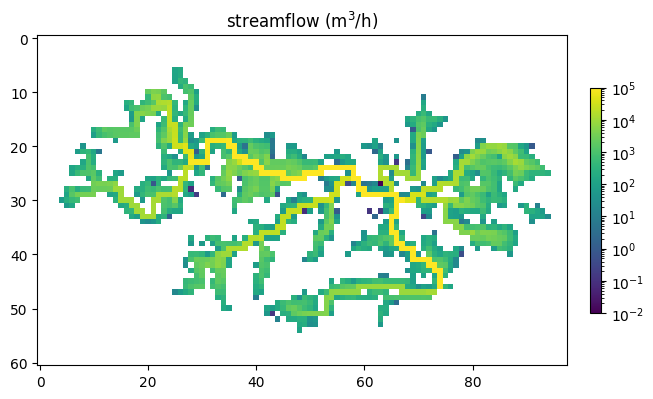

In [24]:
fig = plt.figure(figsize=(16,10))

plt.subplot(121)
im = plt.imshow(streamflow,norm=matplotlib.colors.LogNorm(vmin=1e-2, vmax=1e5))
plt.colorbar(im, fraction=0.02, pad=0.04)
plt.title('streamflow ($\mathregular{m^3}$/h)')

<img src="pftools_figs/研究区.jpg" width="550">

### * def **calculate_subsurface_storage**(porosity, pressure, saturation, specific_storage, dx, dy, dz, mask=None):
### * def **calculate_surface_storage**(pressure, dx, dy, mask=None):
### * def **calculate_water_table_depth**(pressure, saturation, dz):

In [28]:
subsurface_storage = calculate_subsurface_storage(porosity, pressure, saturation, specific_storage, dx, dy, dz, mask=mask10)

In [29]:
surface_storage = calculate_surface_storage(pressure, dx, dy, mask=mask10)

In [33]:
wtdepth = calculate_water_table_depth(pressure, saturation, dz)
wtdepth[mask10[0]<1] = np.nan

Text(0.5, 1.0, 'streamflow ($\\mathregular{m^3}$/h)')

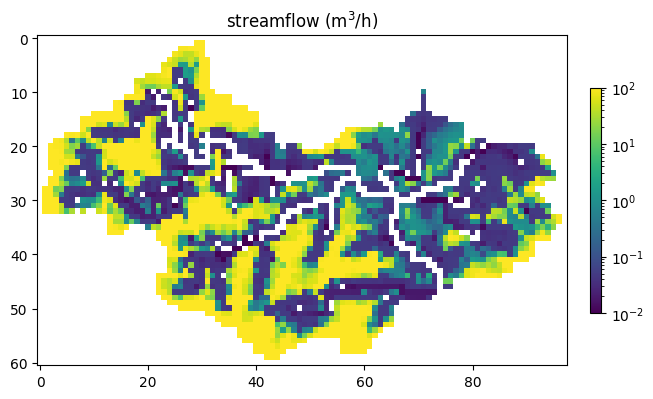

In [34]:
fig = plt.figure(figsize=(16,10))

plt.subplot(121)
im = plt.imshow(wtdepth[::-1],norm=matplotlib.colors.LogNorm(vmin=1e-2, vmax=1e2))
plt.colorbar(im, fraction=0.02, pad=0.04)
plt.title('water table depth (m)')